# Rounded Activation Functions

**Author**: <a href="https://www.linkedin.com/in/christian-oliva-moya-ingeniero/">Christian Oliva Moya</a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In this notebook, the aim is to illustrate with some examples the ideas behind implementing rounded activation functions in TensorFlow. Possible use cases:

1. Rounding the activation function of the input layer to be more robust against adversarial attacks. This idea was used in the undergraduate thesis of <a href="https://www.linkedin.com/in/javier-fontecha-guada%C3%B1o-a11a9a1ba/">Javier Fontecha Guadaño</a>: *"Defense against adversarial attacks on convolutional neural networks"* and has yielded very good results. Where does the idea come from? If an adversarial attack consists of slightly modifying the input data to confuse the model, rounding implies that, even if the input is modified, the activation of the next layer will still have the same values.

2. Rounding at the output of the embedding layer of a neural network trained with NLP. Following the same idea, if for some reason you are trying to find vectors that represent the same thing, this embedding will not return two similar vectors for similar concepts but will return exactly the same vector. This is particularly interesting in topics related to the interpretability of these networks, for example, in sentiment analysis.

3. Rounding in the activation function of the recurrent layer of an RNN (whether Elman, LSTM, or any other type). If the states of an RNN are usually bounded between -1 and 1 due to the use of a tanh, why not round it to have discretized neurons with values -1, 0, or 1? In my thesis, I have explored this idea for interpretability purposes, and it is yielding very good results.

4. Applying rounding of the sigmoid function on one or more variables to create a differentiable boolean mask. This idea, which I have explored with <a href="https://www.linkedin.com/in/pedro-ramon-ventura-gomez/">Pedro Ventura</a>, has led us to publish a complete multi-objective portfolio optimization framework implemented in TensorFlow.

In [ ]:
def plot_figure(x, function, round_function, title, cuts, decimals=None, epsilon=1e-6):
    """
    Plots the original and rounded activation functions side by side.

    Args:
        x (np.ndarray): Input values for the activation functions.
        function (Callable): The original activation function to be plotted.
        round_function (Callable): The rounded activation function to be plotted.
        title (str): Title of the activation function.
        cuts (List[float]): Specific points to highlight on the plots.
        decimals (int, optional): Number of decimals for rounding. Defaults to None.
        epsilon (float, optional): Small value to compute rounded values near cuts. Defaults to 1e-6.
    """

    # Compute the original function and rounded function values
    y = function(x)
    ry = round_function(x)

    # Create a figure with two subplots
    plt.figure(figsize=(12, 3))

    # First subplot: Original function
    plt.subplot(1, 2, 1)
    plt.title("$" + title + "$")
    plt.plot(x, y, ".")
    plt.xlabel("x")
    plt.ylabel("activation")

    # Highlight specific points (cuts) on the original function
    for cut in cuts:
        plt.plot(cut, function(cut), "o", color="orange", markersize=8)
        plt.axhline(function(cut), color="orange", alpha=0.2)
        plt.axvline(cut, color="orange", alpha=0.2)

    # Second subplot: Rounded function
    plt.subplot(1, 2, 2)
    if decimals is not None:
        plt.title("$round(" + title + ", decimals=" + str(decimals) + ")$")
    else:
        plt.title("$round(" + title + ")$")
    plt.plot(x, ry, ".")
    plt.plot(x, y, "-", alpha=0.3)

    # Highlight specific points (cuts) on the rounded function
    for cut in cuts:
        plt.plot(
            [cut - epsilon, cut + epsilon],
            [round_function(cut - epsilon), round_function(cut + epsilon)],
            "o",
            color="orange",
            markersize=8,
        )
        plt.axhline(round_function(cut - epsilon), color="orange", alpha=0.2)
        plt.axhline(round_function(cut + epsilon), color="orange", alpha=0.2)
        plt.axvline(cut, color="orange", alpha=0.2)

    # Label the x-axis and display the plot
    plt.xlabel("x")
    plt.show()

In [3]:
def plot_derivative(x, function, round_function, title, decimals=None, epsilon=1e-6):
    """
    Plots the derivatives of the original and rounded activation functions side by side.

    Args:
        x (np.ndarray): Input values for the activation functions.
        function (Callable): The original activation function.
        round_function (Callable): The rounded activation function.
        title (str): Title of the activation function.
        decimals (int, optional): Number of decimals for rounding. Defaults to None.
        epsilon (float, optional): Small value for numerical stability. Defaults to 1e-6.
    """
    x = tf.constant(x)

    # Compute the derivative of the original function
    with tf.GradientTape() as tape:
        tape.watch(x)
        y = function(x)
        dy_dx = tape.gradient(y, x)

    # Compute the derivative of the rounded function
    with tf.GradientTape() as tape:
        tape.watch(x)
        ry = round_function(x)
        dry_dx = tape.gradient(ry, x)

    # Create a figure with two subplots
    plt.figure(figsize=(12, 3))

    # First subplot: Derivative of the original function
    plt.subplot(1, 2, 1)
    plt.title("Derivative of $" + title + "$")
    plt.plot(x, dy_dx, ".")
    plt.xlabel("x")
    plt.ylabel("derivative")

    # Second subplot: Derivative of the rounded function
    plt.subplot(1, 2, 2)
    if decimals is not None:
        plt.title("Derivative of $round(" + title + ", decimals=" + str(decimals) + ")$")
    else:
        plt.title("Derivative of $round(" + title + ")$")
    plt.plot(x, dry_dx, ".")
    plt.plot(x, dy_dx, ".", alpha=0.05)
    plt.xlabel("x")
    plt.show()

In [4]:
def inv_sigmoid(x):
    """
    Computes the inverse of the sigmoid function.

    Args:
        x (float or np.ndarray): Input value(s) in the range (0, 1).

    Returns:
        float or np.ndarray: The inverse sigmoid value(s), which can be any real number.
    """
    return np.log(x / (1 - x))

## Rounded Sigmoid

In [5]:
def round_sigmoid(decimals=0):
    @tf.custom_gradient
    def my_rounded_sigmoid(x):
        z = tf.nn.sigmoid(x)
        scale = 10**decimals
        output = tf.math.round(z * scale) / scale

        def backward(dy):
            custom_grad = z * (1 - z)
            return dy * custom_grad

        return output, backward

    return my_rounded_sigmoid

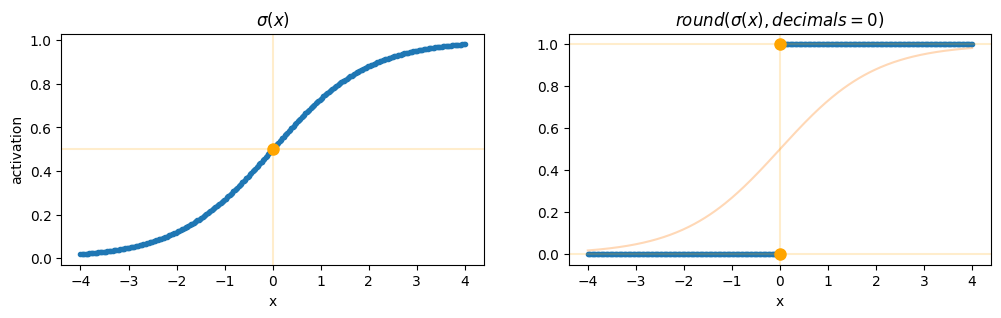

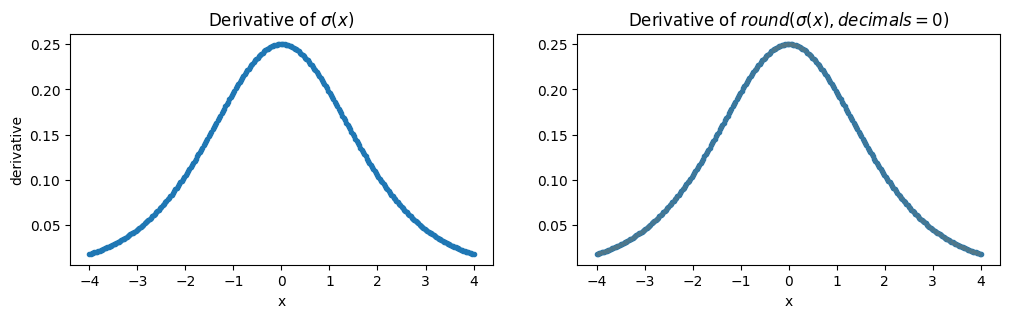

In [6]:
x = np.linspace(-4, 4, 300).astype(np.float32)
y = tf.nn.sigmoid(x)
ry = round_sigmoid(decimals=0)(x)

plot_figure(x, tf.nn.sigmoid, round_sigmoid(decimals=0), "\sigma(x)", [0.0], decimals=0)
plot_derivative(x, tf.nn.sigmoid, round_sigmoid(decimals=0), "\sigma(x)", decimals=0)

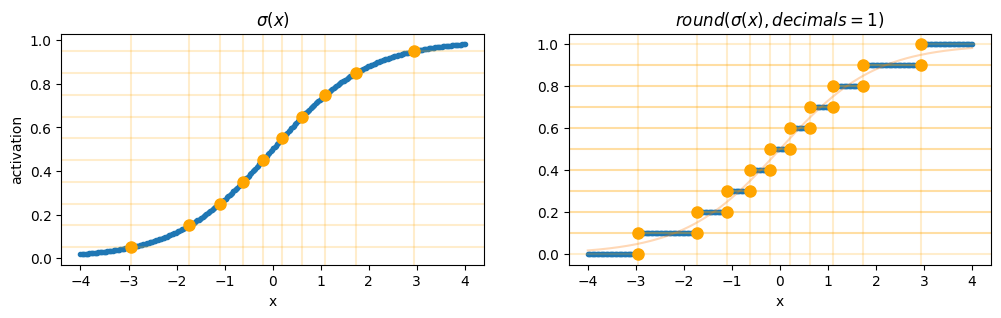

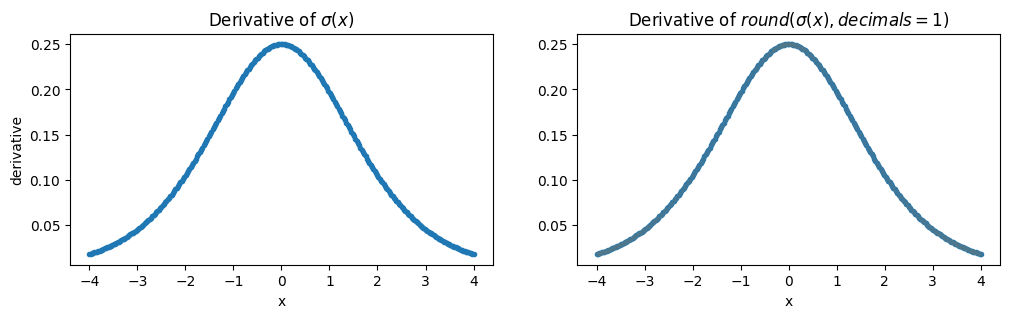

In [7]:
x = np.linspace(-4, 4, 300).astype(np.float32)
y = tf.nn.sigmoid(x)
ry = round_sigmoid(decimals=1)(x)

plot_figure(
    x,
    tf.nn.sigmoid,
    round_sigmoid(decimals=1),
    "\sigma(x)",
    [inv_sigmoid(i) for i in np.arange(0.05, 1.01, 0.1)],
    decimals=1,
)
plot_derivative(x, tf.nn.sigmoid, round_sigmoid(decimals=1), "\sigma(x)", decimals=1)

## Rounded Tanh

In [8]:
def round_tanh(decimals=0):
    @tf.custom_gradient
    def my_rounded_tanh(x):
        z = tf.tanh(x)
        scale = 10**decimals
        output = tf.math.round(z * scale) / scale

        def backward(dy):
            custom_grad = 1 - tf.square(z)
            return dy * custom_grad

        return output, backward

    return my_rounded_tanh

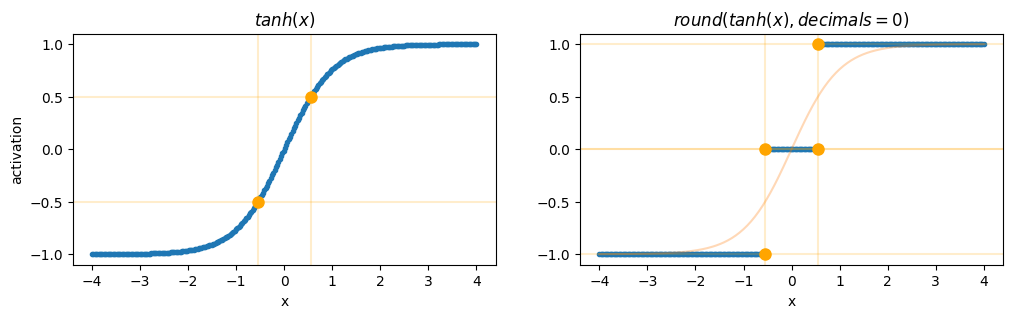

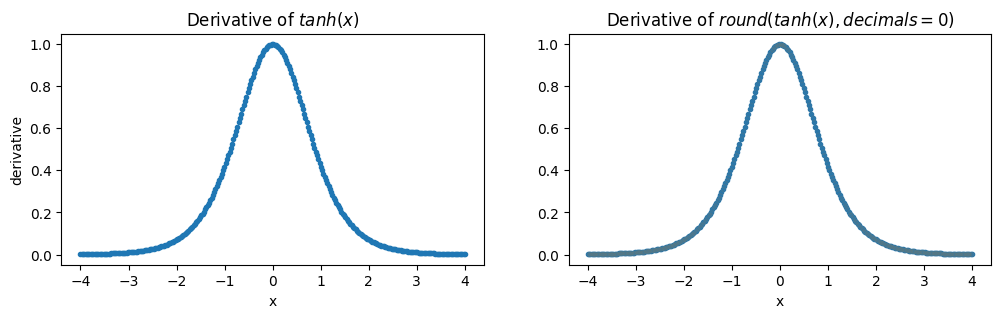

In [9]:
x = np.linspace(-4, 4, 300).astype(np.float32)
y = tf.tanh(x)
ry = round_tanh(decimals=0)(x)

plot_figure(
    x,
    tf.nn.tanh,
    round_tanh(decimals=0),
    "tanh(x)",
    [np.arctanh(-0.5), np.arctanh(0.5)],
    decimals=0,
)
plot_derivative(x, tf.nn.tanh, round_tanh(decimals=0), "tanh(x)", decimals=0)

## Rounded ReLU

In [10]:
def round_relu(decimals=0):
    @tf.custom_gradient
    def my_rounded_relu(x):
        z = tf.nn.relu(x)
        scale = 100**decimals
        output = tf.math.round(z * scale) / scale

        def backward(dy):
            custom_grad = tf.cast(z > 0, dtype=tf.float32)
            return dy * custom_grad

        return output, backward

    return my_rounded_relu

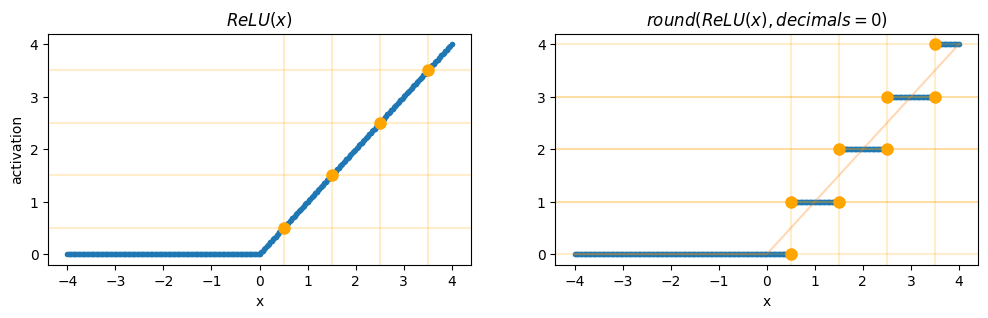

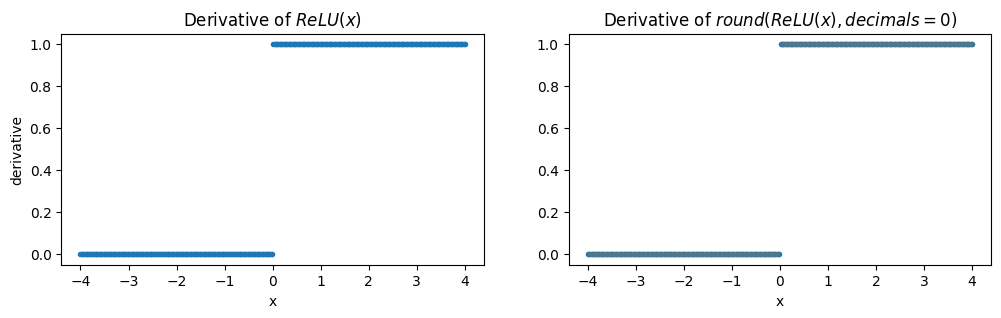

In [11]:
x = np.linspace(-4, 4, 300).astype(np.float32)
y = tf.nn.relu(x)
ry = round_relu(decimals=0)(x)

plot_figure(x, tf.nn.relu, round_relu(decimals=0), "ReLU(x)", [0.5, 1.5, 2.5, 3.5], decimals=0)
plot_derivative(x, tf.nn.relu, round_relu(decimals=0), "ReLU(x)", decimals=0)

# Rounded ReLU with different step width and height

In [12]:
def relu_ap(a=1.0, p=1.0):
    @tf.function
    def my_relu_ap(x):
        z = x / p * a
        return tf.maximum(0.0, z)

    return my_relu_ap


def round_relu_ap(a=1.0, p=1.0):
    @tf.custom_gradient
    def my_rounded_relu(x):
        z = tf.math.round(x / p) * a
        output = tf.maximum(0.0, z)

        def backward(dy):
            custom_grad = tf.cast(x > 0, dtype=tf.float32) * (a / p)
            return dy * custom_grad

        return output, backward

    return my_rounded_relu

### a=1, p=1 make ReLUap = ReLU

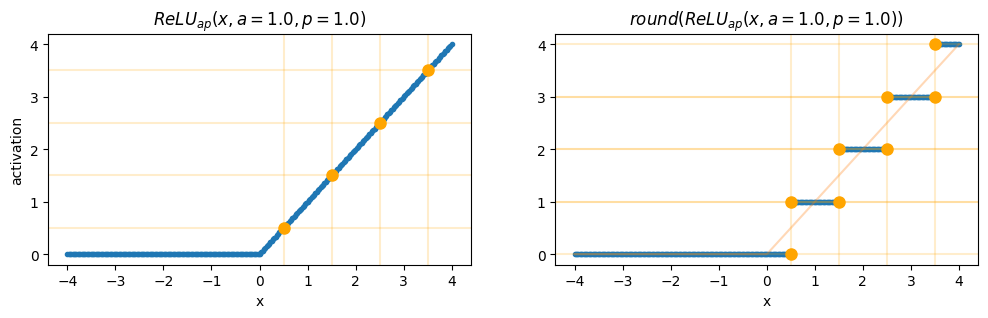

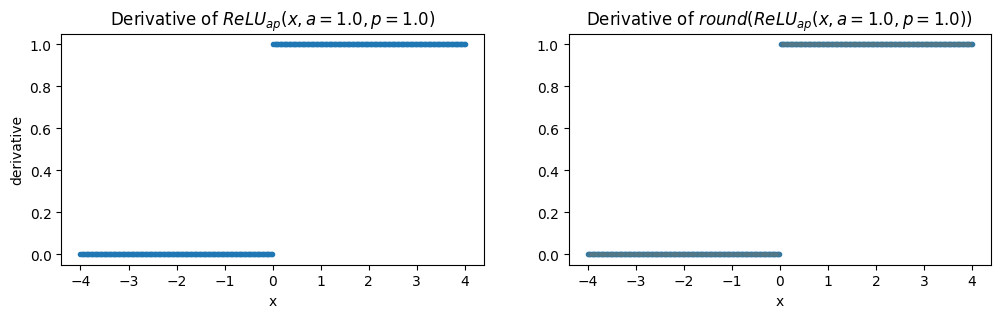

In [13]:
a = 1.0  # height
p = 1.0  # width

x = np.linspace(-4, 4, 300).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [0.5, 1.5, 2.5, 3.5],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

### If we want a larger height, we change $a$

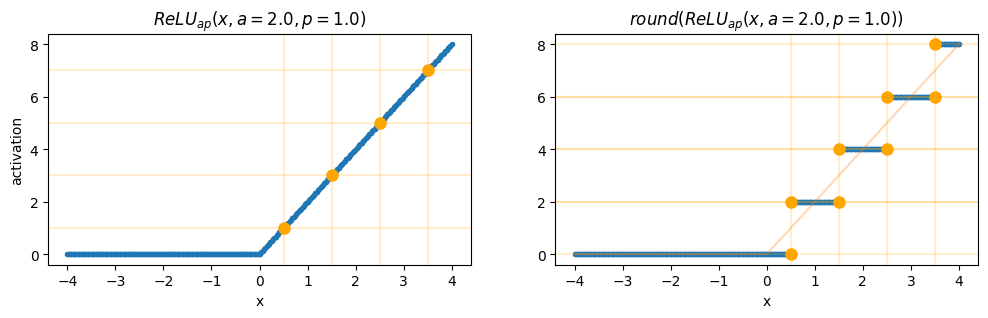

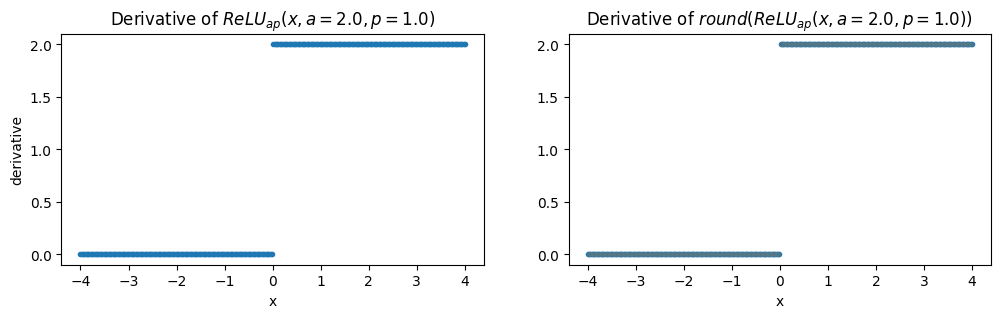

In [14]:
a = 2.0  # height
p = 1.0  # width

x = np.linspace(-4, 4, 300).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [0.5, 1.5, 2.5, 3.5],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

### If we want a larger step width, we change $p$

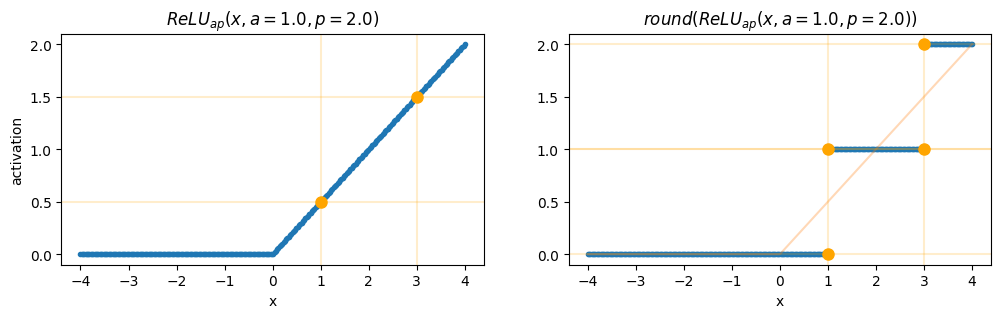

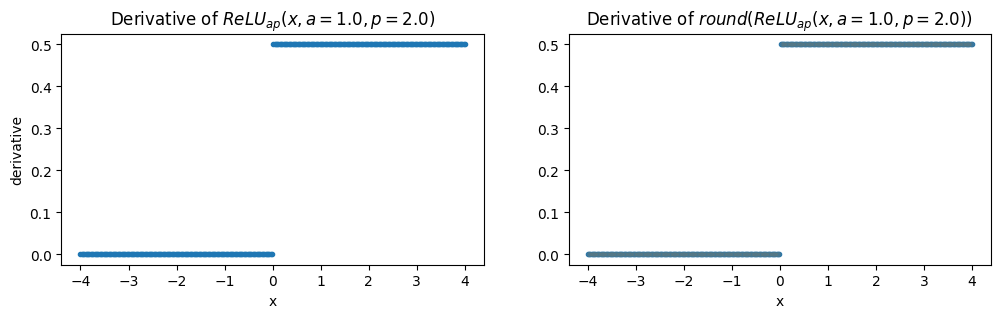

In [15]:
a = 1.0  # height
p = 2.0  # width

x = np.linspace(-4, 4, 300).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [1.0, 3.0],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

### Of course, we can change $a$ and $p$ at the same time

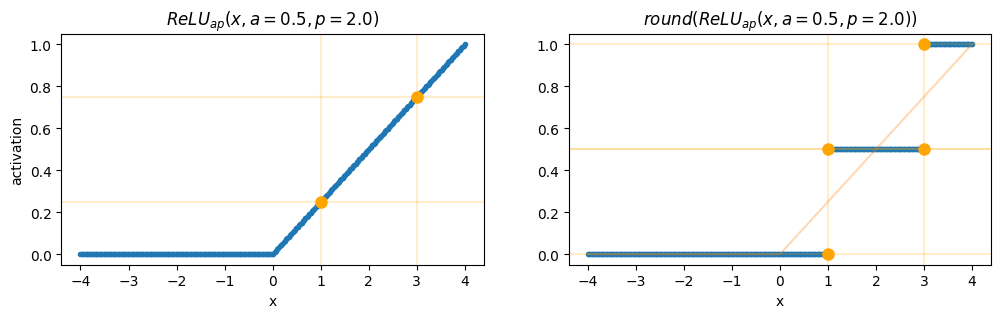

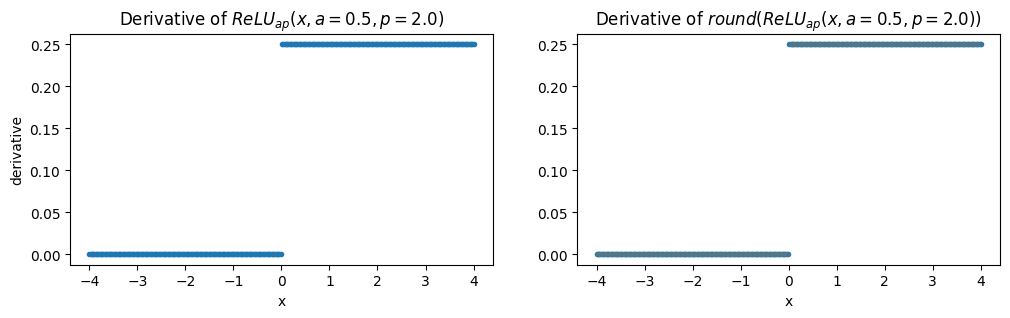

In [16]:
a = 0.5  # height
p = 2.0  # width

x = np.linspace(-4, 4, 300).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [1.0, 3.0],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

### What would happen if we look for a continuous step function?

# Step function

In [17]:
def step_ap(a=1.0, p=1.0):
    pi = np.pi
    w = 2 * pi / p

    @tf.function
    def my_step_ap(x):
        z = a / (2 * pi) * (w * x - tf.sin(w * x))
        return tf.maximum(0.0, z)

    return my_step_ap


def round_step_ap(a=1.0, p=1.0):
    pi = np.pi
    w = 2 * pi / p

    @tf.custom_gradient
    def my_round_step(x):
        z = step_ap(a=a, p=p)(x)
        output = tf.math.round(z)

        def backward(dy):
            custom_grad = tf.cast(x > 0, dtype=tf.float32) * (a / p) * (1 - tf.cos(w * x))
            return dy * custom_grad

        return output, backward

    return my_round_step

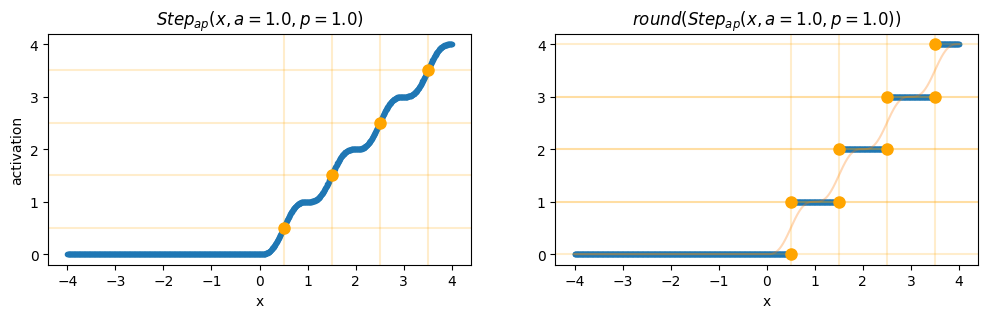

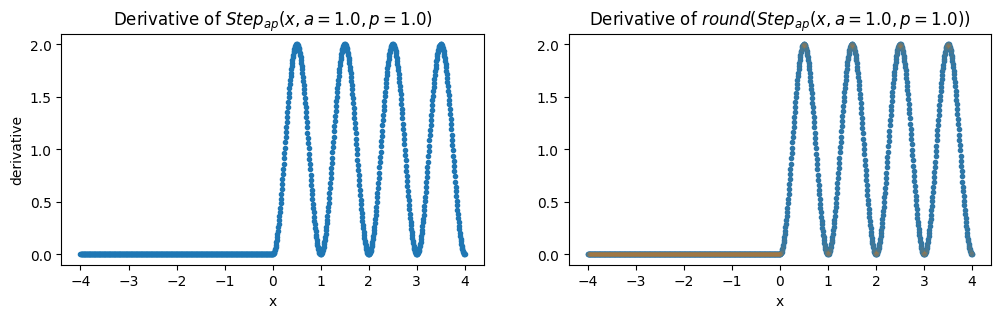

In [18]:
a = 1.0  # height
p = 1.0  # width

x = np.linspace(-4, 4, 1000).astype(np.float32)
y = step_ap(a, p)(x)
ry = round_step_ap(a, p)(x)

plot_figure(
    x,
    step_ap(a, p),
    round_step_ap(a, p),
    "Step_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [0.5, 1.5, 2.5, 3.5],
)
plot_derivative(
    x,
    step_ap(a, p),
    round_step_ap(a, p),
    "Step_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

### The rounding of the step function is the same as the rounding of the ReLU!!

### What if we use the derivative of this function with the rounded ReLU?

## Rounded ReLU with step derivative

In [19]:
def relu_ap(a=1.0, p=1.0):
    @tf.function
    def my_relu_ap(x):
        z = x / p * a
        return tf.maximum(0.0, z)

    return my_relu_ap


def round_relu_ap_custom_deriv(a=1.0, p=1.0):
    pi = np.pi
    w = 2 * pi / p

    @tf.custom_gradient
    def my_rounded_relu(x):
        z = tf.math.round(x / p) * a
        output = tf.maximum(0.0, z)

        def backward(dy):
            custom_grad = tf.cast(x > 0, dtype=tf.float32) * (a / p) * (1 - tf.cos(w * x))
            return dy * custom_grad

        return output, backward

    return my_rounded_relu

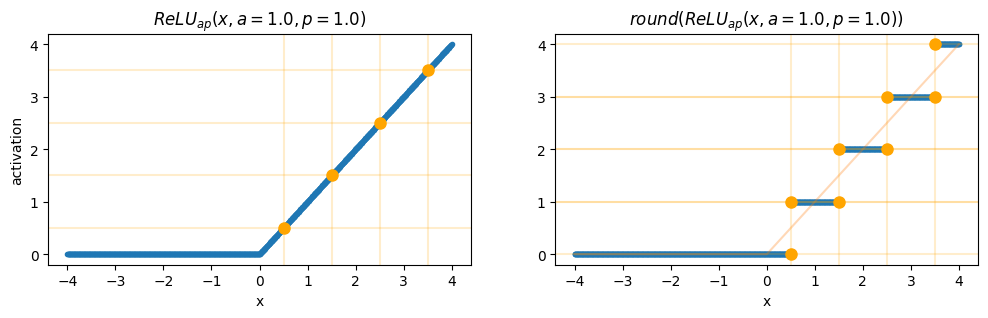

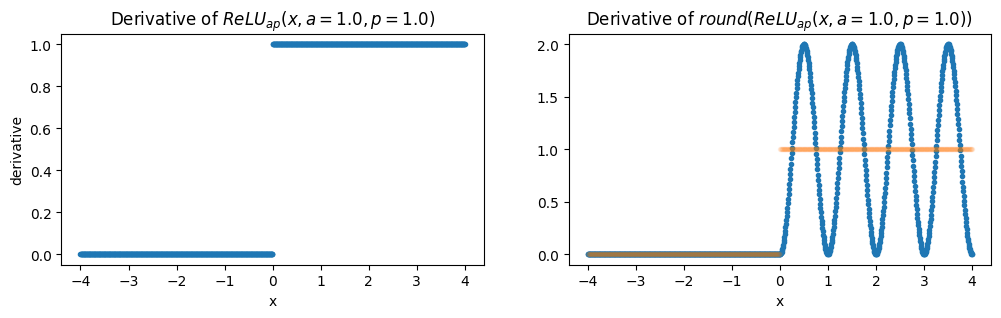

In [20]:
a = 1.0  # height
p = 1.0  # width

x = np.linspace(-4, 4, 1000).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap_custom_deriv(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap_custom_deriv(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [0.5, 1.5, 2.5, 3.5],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap_custom_deriv(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

### The maximum value of the derivative is right at the steps!!

Maybe we are interested in having a high derivative at the edges to move away from there and settle in the centers of the steps.

### See how the derivatives change, but always with the peaks at the steps!!!

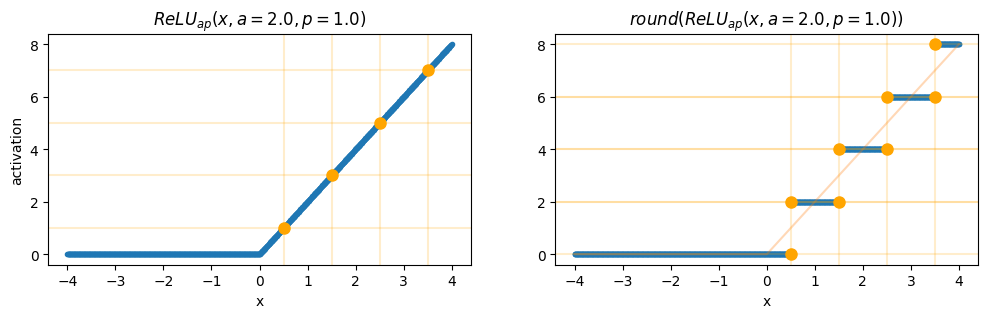

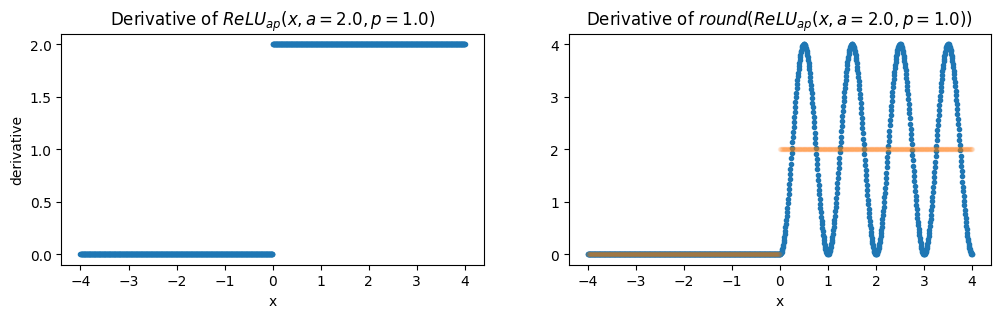

In [21]:
a = 2.0  # height
p = 1.0  # width

x = np.linspace(-4, 4, 1000).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap_custom_deriv(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap_custom_deriv(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [0.5, 1.5, 2.5, 3.5],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap_custom_deriv(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

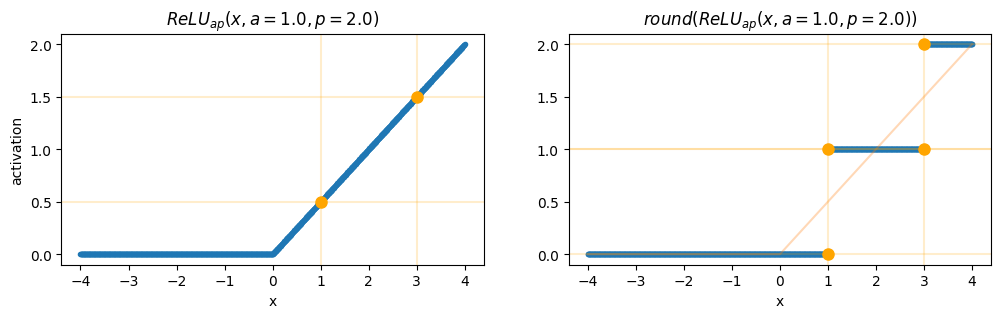

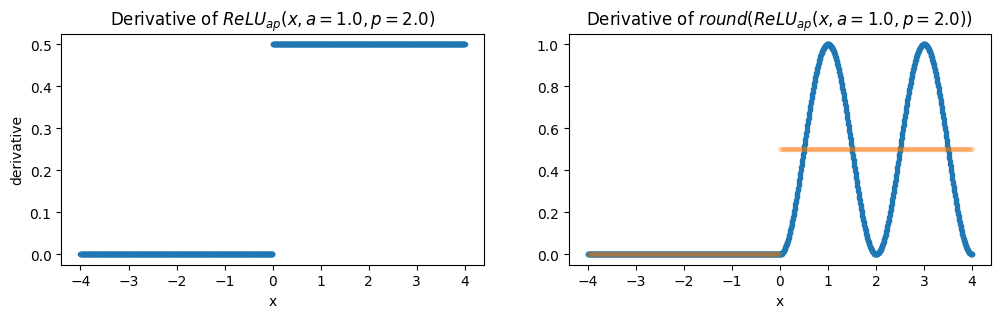

In [22]:
a = 1.0  # height
p = 2.0  # width

x = np.linspace(-4, 4, 1000).astype(np.float32)
y = relu_ap(a, p)(x)
ry = round_relu_ap_custom_deriv(a, p)(x)

plot_figure(
    x,
    relu_ap(a, p),
    round_relu_ap_custom_deriv(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
    [1.0, 3.0],
)
plot_derivative(
    x,
    relu_ap(a, p),
    round_relu_ap_custom_deriv(a, p),
    "ReLU_{ap}(x, a=" + str(a) + ", p=" + str(p) + ")",
)

In [23]:
# Export to HTML
!jupyter nbconvert --to html FuncionesDeActivacionRedondeadas.ipynb

[NbConvertApp] Converting notebook FuncionesDeActivacionRedondeadas.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 24 image(s).
[NbConvertApp] Writing 1176077 bytes to FuncionesDeActivacionRedondeadas.html
